# Spectral fitting example (AGN)


This notebook fits the spectrum of a simulated AGN observation with COSI using the same 3ML workflow as the Crab spectral fitting tutorial.

This notebook fits a time-cut NGC 4151 binned dataset with a separate time-cut background template. The orientation can be toggled between the full three-month history and an NGC 4151 FOV-cut history to test the impact on the spectral fit.


In [75]:
from cosipy import BinnedData
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.event_selection import GoodTimeInterval
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file

from cosipy.statistics import PoissonLikelihood
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import BinnedThreeMLModelFolding, BinnedInstrumentResponse, BinnedThreeMLPointSourceResponse
from cosipy.data_io import EmCDSBinnedData

from histpy import Histogram

import sys

import astropy.units as u
from astropy.coordinates import SkyCoord

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from threeML import PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter, Cutoff_powerlaw, Powerlaw, Line

from pathlib import Path

%matplotlib inline


## Download and read in binned data


Define the paths to the NGC 4151 data, time-cut background, detector response, orientation file, and yaml configuration. The data and background are expected to be binned before running this notebook.


In [76]:
analysis_dir = Path.cwd()
if not (analysis_dir / "agn.yaml").exists():
    repo_notebook_dir = Path("/Users/parshadkp/Software/cosipy/docs/tutorials/spectral_fits/continuum_fit/AGN")
    if repo_notebook_dir.exists():
        analysis_dir = repo_notebook_dir

binned_data_file = Path("/Users/parshadkp/Software/COSI_Data/DC4_Files/NGC_4151__3months_binned_data_filtered_with_SAAcut.hdf5") # NGC 4151 DC4 data 
# binned_data_file = Path("/Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/Paper_Models/NGC_4151_ec200_DC3_COSI_cpl_pl.hdf5") # NGC 4151 adjusted non-thermal tail

# binned_data_file = Path("/Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/Paper_Models/NGC_4151_ec200_DC3_COSI_cpl.hdf5")

time_cut_background_file = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck_ngc4151_in_fov_binned.hdf5"
)

orientation_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori"
response_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"
agn_config = analysis_dir / "agn.yaml"

exposure_multiplier = 81
count_exposure_multiplier = exposure_multiplier
obs_months = exposure_multiplier * 3

# Run both orientation choices against the same time-cut data/background.
primary_case_key = "time_cut_ori"
include_nonthermal_tail = True
tail_ratio_at_200keV = 0.05  # Use 0.15 for NGC_4151_ec200_DC3_COSI_cpl_pl.hdf5.
max_offaxis = 60 * u.deg
earth_occ = True

source_label = "NGC 4151"
source_l = 155.07 * u.deg
source_b = 75.06 * u.deg
source_coord = SkyCoord(l=source_l, b=source_b, frame="galactic")

Read in the spacecraft orientation file and build both the full and FOV-cut spacecraft histories.


In [77]:
# fetch_wasabi_file(
#     "COSI-SMEX/DC2/Data/Orientation/20280301_3_month_with_orbital_info.ori",
#     output=str(orientation_path),
#     checksum="416fcc296fc37a056a069378a2d30cb2",
# )
sc_orientation_full = SpacecraftHistory.open(orientation_path)
source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord,
    sc_orientation_full,
    max_offaxis,
    earth_occ=earth_occ,
)
sc_orientation_time_cut = sc_orientation_full.apply_gti(source_gti)

orientation_cases = {
    "full_ori": {
        "label": "Full .ori",
        "sc_orientation": sc_orientation_full,
        "color": "blue",
        "linestyle": "dashdot",
    },
    "time_cut_ori": {
        "label": f"{source_label} FOV-cut .ori",
        "sc_orientation": sc_orientation_time_cut,
        "color": "red",
        "linestyle": "dashdot",
    },
}

full_livetime = sc_orientation_full.cumulative_livetime().to_value(u.s)
time_cut_livetime = sc_orientation_time_cut.cumulative_livetime().to_value(u.s)

print(f"Full orientation livetime: {full_livetime:,.1f} s")
print(f"Time-cut orientation livetime: {time_cut_livetime:,.1f} s")
print(f"Time-cut/full livetime fraction: {time_cut_livetime / full_livetime:.4f}")

Full orientation livetime: 6,579,555.0 s
Time-cut orientation livetime: 980,415.0 s
Time-cut/full livetime fraction: 0.1490


Load the binned NGC 4151 data and time-cut background template. The data are projected onto the measured-energy and Compton-data-space axes used by the continuum response.


In [78]:
if not binned_data_file.exists():
    raise FileNotFoundError(
        f"Set binned_data_file to your binned data HDF5 file: {binned_data_file}"
    )
if not time_cut_background_file.exists():
    raise FileNotFoundError(
        f"Set time_cut_background_file to your binned background HDF5 file: {time_cut_background_file}"
    )

source_hist_full = Histogram.open(binned_data_file)
time_cut_background = Histogram.open(time_cut_background_file)

source_hist = source_hist_full.project("Em", "Phi", "PsiChi") * count_exposure_multiplier
total_bkg = time_cut_background.project("Em", "Phi", "PsiChi") * count_exposure_multiplier
data_hist = source_hist + total_bkg


def make_background_distribution():
    # Build a fresh copy for each fit because FreeNormBinnedBackground normalizes its input.
    total_bkg_for_fit = total_bkg.copy()
    total_bkg_for_fit += sys.float_info.min
    return {"total_bkg": total_bkg_for_fit}

Fetch and open the response.


In [79]:
# fetch_wasabi_file(
#     "COSI-SMEX/develop/Data/Responses/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5",
#     output=str(response_path),
#     checksum="7121f094be50e7bfe9b31e53015b0e85",
# )
dr = FullDetectorResponse.open(str(response_path))


## Perform spectral fit


Define a helper that sets the background parameter, which is used to fit the amplitude of the background, and instantiates a COSI 3ML plugin for a given spacecraft history.


In [80]:
def build_cosi_plugin(sc_orientation, plugin_name="cosi"):
    # Wrap the raw BinnedData object into the appropriate data interface.
    data = EmCDSBinnedData(data_hist)

    # Use the background model to initialize a background expectation interface.
    bkg = FreeNormBinnedBackground(make_background_distribution(),
                                   sc_history=sc_orientation,
                                   copy=False)

    # Wrap the raw response with the BinnedInstrumentResponse interface implementation.
    instrument_response = BinnedInstrumentResponse(dr, data)

    # Initialize the 3ML point-source response.
    psr = BinnedThreeMLPointSourceResponse(data=data,
                                           instrument_response=instrument_response,
                                           sc_history=sc_orientation,
                                           energy_axis=dr.axes["Ei"],
                                           polarization_axis=dr.axes["Pol"] if "Pol" in dr.axes.labels else None,
                                           nside=2 * data.axes["PsiChi"].nside)

    # Pass the 3ML point-source response to the interface implementation that performs the folding with the spectrum.
    response = BinnedThreeMLModelFolding(data=data, point_source_response=psr)

    # Likelihood to use.
    like_fun = PoissonLikelihood(data, response, bkg)

    # Initialize 3ML plugin.
    cosi = ThreeMLPluginInterface(plugin_name,
                                  like_fun,
                                  response,
                                  bkg)

    # Initialize background parameters, considered as nuisance parameters.
    for bkg_label in bkg.labels:
        cosi.bkg_parameter[bkg_label] = Parameter(bkg_label,
                                                  200.0,
                                                  min_value=0.0,
                                                  max_value=10000.0,
                                                  delta=0.05,
                                                  unit=u.Hz)

    return {
        "data": data,
        "bkg": bkg,
        "instrument_response": instrument_response,
        "psr": psr,
        "response": response,
        "cosi": cosi,
    }

Define NGC 4151 at the known location with a cutoff-power-law thermal component and a power-law tail, then add the components to the model.


Build independent plugins and models for the full and FOV-cut spacecraft histories, then perform a maximum likelihood fit for each case.


In [81]:
K_inj = (0.15 * exposure_multiplier) / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.75

spectrum_inj_ec200 = Cutoff_powerlaw()

spectrum_inj_ec200.K.value = K_inj.value
spectrum_inj_ec200.piv.value = piv_inj.value
spectrum_inj_ec200.xc.value = xc_inj.value
spectrum_inj_ec200.index.value = index_inj

spectrum_inj_ec200.K.unit = K_inj.unit
spectrum_inj_ec200.piv.unit = piv_inj.unit
spectrum_inj_ec200.xc.unit = xc_inj.unit

K_inj = 0.1 * spectrum_inj_ec200.evaluate_at(1000) / u.cm / u.cm / u.s / u.keV
piv_inj = 1000. * u.keV
index_inj = -3.8

spectrum_inj_ec200_PL = Powerlaw()

spectrum_inj_ec200_PL.K.value = K_inj.value
spectrum_inj_ec200_PL.piv.value = piv_inj.value
spectrum_inj_ec200_PL.index.value = index_inj

spectrum_inj_ec200_PL.K.unit = K_inj.unit
spectrum_inj_ec200_PL.piv.unit = piv_inj.unit

spectrum_inj_ec200_total = spectrum_inj_ec200 + spectrum_inj_ec200_PL

In [ ]:
def build_ngc4151_model():
    # Give it some harsher initial guesses.
    K = 1e-5 / u.cm / u.cm / u.s / u.keV
    piv = 200. * u.keV
    xc = 100. * u.keV
    index = -1.75

    spectrum_cpl = Cutoff_powerlaw()

    spectrum_cpl.K.value = K.value
    spectrum_cpl.piv.value = piv.value
    spectrum_cpl.xc.value = xc.value
    spectrum_cpl.index.value = index
    spectrum_cpl.index.fix = True

    # Keep the hard bounds broad enough that covariance samples are not clipped.
    spectrum_cpl.K.min_value = 1e-10
    spectrum_cpl.K.max_value = 10
    spectrum_cpl.xc.min_value = 10
    spectrum_cpl.xc.max_value = 10000
    # spectrum_cpl.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
    # spectrum_cpl.index.max_value = 1

    # spectrum_cpl.K.delta = 0.05
    # spectrum_cpl.xc.delta = 10
    # spectrum_cpl.index.delta = 0.15

    spectrum_cpl.K.unit = K.unit
    spectrum_cpl.piv.unit = piv.unit
    spectrum_cpl.xc.unit = xc.unit

    spectral_shape = spectrum_cpl

    if include_nonthermal_tail:
        # Put the tail in the same point source as the thermal component.
        # This matches the injected model structure and avoids a cache issue
        # from fitting two linked point sources at the same sky position.
        K_tail = tail_ratio_at_200keV * spectrum_cpl.K.value / u.cm / u.cm / u.s / u.keV
        piv_tail = 200. * u.keV
        index_tail = -3.8

        spectrum_tail = Powerlaw()
        spectrum_tail.K.value = K_tail.value
        spectrum_tail.piv.value = piv_tail.value
        spectrum_tail.index.value = index_tail
        spectrum_tail.index.fix = True

        spectrum_tail.K.min_value = 1e-12
        spectrum_tail.K.max_value = 10
        spectrum_tail.index.min_value = -5
        spectrum_tail.index.max_value = 1
        spectrum_tail.index.delta = 0.25

        spectrum_tail.K.unit = K_tail.unit
        spectrum_tail.piv.unit = piv_tail.unit

        spectral_shape = spectrum_cpl + spectrum_tail

    ngc4151 = PointSource("ngc4151",     # Name of source (arbitrary, but needs to be unique)
                          l=source_l.to_value(u.deg),
                          b=source_b.to_value(u.deg),
                          spectral_shape=spectral_shape)

    model = Model(ngc4151)

    if include_nonthermal_tail:
        link_function = Line(a=0.0, b=tail_ratio_at_200keV)
        link_function.a.fix = True
        link_function.b.fix = True
        model.link(
            model.ngc4151.spectrum.main.composite.K_2,
            model.ngc4151.spectrum.main.composite.K_1,
            link_function,
        )

    return model

#### The model-building function above creates fresh source objects for each orientation fit. The active model is built independently inside each orientation fit.

In [92]:
fit_cases = {}

for case_key, case in orientation_cases.items():
    print(f"\nFitting {case['label']} ...")

    fit_case = dict(case)
    fit_case.update(build_cosi_plugin(case["sc_orientation"], plugin_name=f"cosi_{case_key}"))
    fit_case["model"] = build_ngc4151_model()
    fit_case["plugins"] = DataList(fit_case["cosi"])
    fit_case["like"] = JointLikelihood(fit_case["model"], fit_case["plugins"], verbose=False)

    _ = fit_case["like"].fit()
    fit_case["results"] = fit_case["like"].results
    fit_case["expectation"] = fit_case["response"].expectation()

    fit_cases[case_key] = fit_case

primary_fit = fit_cases[primary_case_key]
data = primary_fit["data"]
bkg = primary_fit["bkg"]
response = primary_fit["response"]
cosi = primary_fit["cosi"]
like = primary_fit["like"]
results = primary_fit["results"]
expectation = primary_fit["expectation"]


Fitting Full .ori ...


16:33:16 INFO      set the minimizer to minuit                                             ]8;id=119833;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=523938;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in lo

16:34:31 WARNING   50.22 percent of samples have been thrown away because they failed the  ]8;id=73106;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=224918;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

Best fit values:

...

         ERROR     │ 1 │ ngc4151_spectrum_main_composite_xc_1       │  1.6579   │  0.0020   ]8;id=139901;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py\minuit_minimizer.py]8;;\:]8;id=972371;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py#169\169]8;;\
                  │            │            │    1    │    4    │       │                                          

         ERROR     │ 2 │ ngc4151_spectrum_main_composite_K_2_Line_b │-13.116e-3 │ 0.023e-3  ]8;id=238954;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py\minuit_minimizer.py]8;;\:]8;id=469961;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py#169\169]8;;\
                  │            │            │         │         │       │                                          

         ERROR     │ 3 │ total_bkg                                  │2.077415e3 │0.000007e3 ]8;id=849771;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py\minuit_minimizer.py]8;;\:]8;id=614334;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py#169\169]8;;\
                  │            │            │    0    │  10000  │       │                                          

         ERROR     └───┴────────────────────────────────────────────┴───────────┴────────── ]8;id=428523;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py\minuit_minimizer.py]8;;\:]8;id=9063;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py#169\169]8;;\
                  ─┴────────────┴────────────┴─────────┴─────────┴───────┘                                         

FitFailed: MIGRAD call failed. This is usually due to unconstrained parameters.

## Error propagation and plotting


The summaries of the results above give the optimal values of the parameters, as well as the errors. Propagate the errors to the `evaluate_at` method of each fitted source spectrum.


In [84]:
for case_key, fit_case in fit_cases.items():
    results = fit_case["results"]

    print(f"\n{fit_case['label']} fit results")
    print(results.display())

    source_parameters = {par.name: results.get_variates(par.path)
                         for par in results.optimized_model["ngc4151"].parameters.values()
                         if par.free}
    fit_case["flux_errors"] = results.propagate(
        results.optimized_model["ngc4151"].spectrum.main.shape.evaluate_at,
        **source_parameters,
    )

    print(results.optimized_model["ngc4151"])


Full .ori fit results


Best fit values:

,result,unit
parameter,,
ngc4151.spectrum.main.composite.K_1,(5.72 +/- 0.04) x 10^-3,1 / (keV s cm2)
ngc4151.spectrum.main.composite.xc_1,(1.0000 +/- 0.0019) x 10,keV
total_bkg,(3.08850 +/- 0.00009) x 10^2,Hz


Correlation matrix:

1.00,-0.00,-0.60
-0.00,1.00,0.00
-0.60,0.00,1.00


...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi_time_cut_ori,-18051300785.785194
total,-18051300785.785194


Values of statistical measures:

,statistical measures
AIC,-36102601565.57028
BIC,-36102601534.52767


None
  * ngc4151 (point source):
    * position:
      * l:
        * value: 155.07
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: 75.06
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * composite:
          * K_1:
            * value: 0.007186162862447674
            * desc: Normalization (differential flux at the pivot value)
            * min_value: 1.0e-10
            * max_value: 10.0
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * piv_1:
            * value: 200.0
            * desc: Pivot value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * index_1:
            * value: -1.75
           

Evaluate the flux and errors at a range of energies for the fitted and injected spectra.


In [85]:
energy = np.geomspace(200 * u.keV, 5 * u.MeV).to_value(u.keV)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    if include_nonthermal_tail:
        flux_inj[i] = spectrum_inj_ec200_total.evaluate_at(e)
    else:
        flux_inj[i] = spectrum_inj_ec200.evaluate_at(e)

for case_key, fit_case in fit_cases.items():
    flux_lo = np.zeros_like(energy)
    flux_median = np.zeros_like(energy)
    flux_hi = np.zeros_like(energy)

    for i, e in enumerate(energy):
        flux = fit_case["flux_errors"](e)
        flux_median[i] = flux.median
        flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)

    fit_case["flux_median"] = flux_median
    fit_case["flux_lo"] = flux_lo
    fit_case["flux_hi"] = flux_hi

binned_energy_edges = data_hist.axes["Em"].edges.value
binned_energy = 0.5 * (binned_energy_edges[1:] + binned_energy_edges[:-1])

primary_fit = fit_cases[primary_case_key]
data = primary_fit["data"]
bkg = primary_fit["bkg"]
response = primary_fit["response"]
expectation = primary_fit["expectation"]

Plot the injected spectrum and the fitted spectra from both spacecraft-history choices.


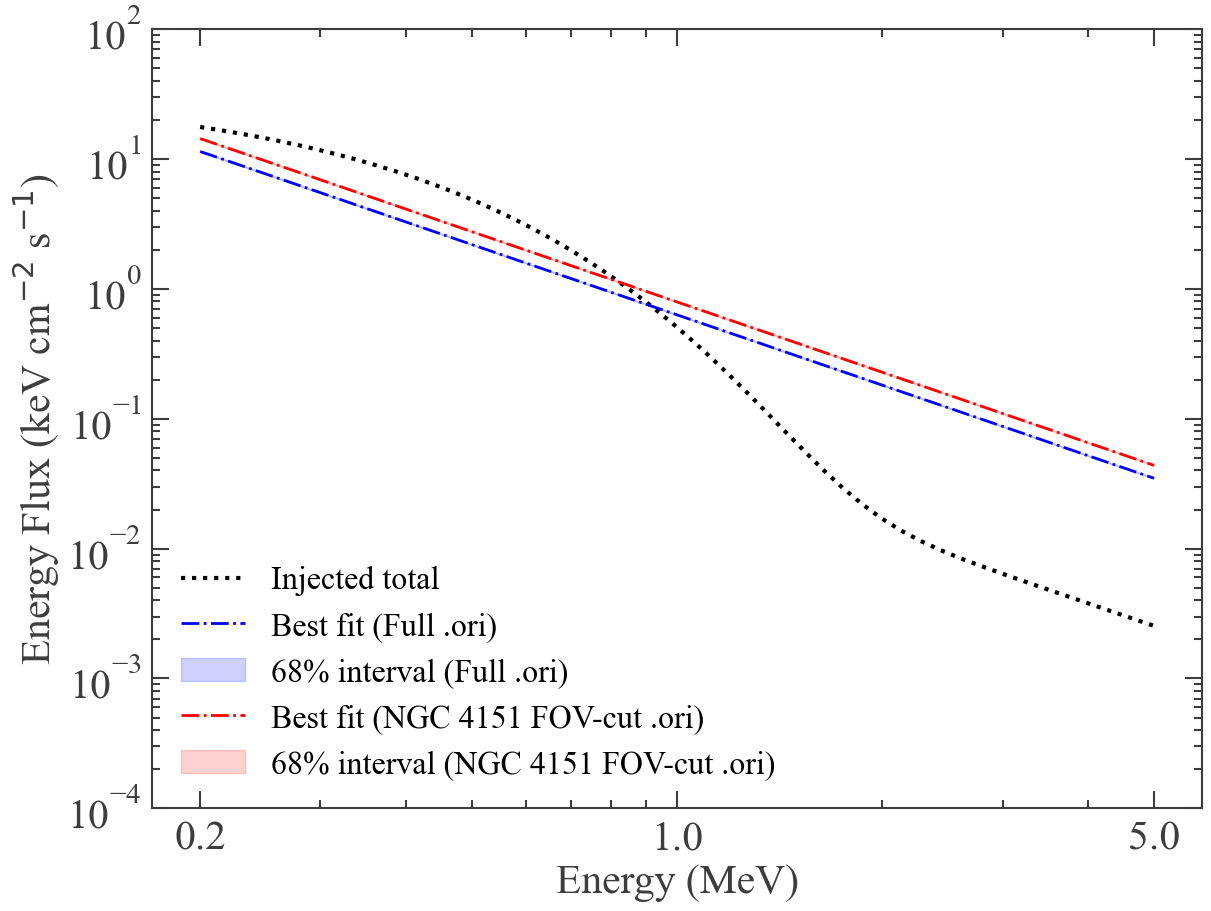

In [87]:
FONT_SIZE = 30
plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update({
    "font.weight": "550",
    "axes.titleweight": "550",
    "axes.labelweight": "550",
})


def style_axis(ax):
    ax.xaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", top=True, pad=8, labelsize=FONT_SIZE)
    ax.xaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", top=True, pad=8)
    ax.yaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", right=True, pad=8, labelsize=FONT_SIZE)
    ax.yaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", right=True, pad=8)
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)


fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)

injected_label = "Injected total" if include_nonthermal_tail else "Injected thermal"
ax.plot(energy / 1000, energy * energy * flux_inj, color="black", ls=":", lw=3, label=injected_label)

for case_key, fit_case in fit_cases.items():
    color = fit_case["color"]
    label = fit_case["label"]
    ax.plot(
        energy / 1000,
        energy * energy * fit_case["flux_median"],
        color=color,
        lw=2,
        linestyle=fit_case["linestyle"],
        label=f"Best fit ({label})",
    )
    ax.fill_between(
        energy / 1000,
        energy * energy * fit_case["flux_lo"],
        energy * energy * fit_case["flux_hi"],
        alpha=0.18,
        color=color,
        label=f"68% interval ({label})",
    )
ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

ax.set_ylim(1e-4, 100)

_ = ax.legend(fontsize=23, loc="lower left", frameon=False)

Plot the primary fitted spectrum convolved with the response plus the fitted background, as well as the simulated source+background counts.


In [ ]:
expectation_bkg = bkg.expectation(copy=True)

source_model_counts = expectation.project("Em").to_dense(copy=False).contents
background_counts = expectation_bkg.project("Em").to_dense(copy=False).contents
model_counts = source_model_counts + background_counts
data_counts = data.data.project("Em").to_dense(copy=False).contents

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)

ax.stairs(data_counts, binned_energy_edges / 1000, label="NGC 4151 + Background Data", color="black", linestyle=":")
ax.errorbar(binned_energy / 1000, data_counts, yerr=np.sqrt(data_counts), color="black", linewidth=0, elinewidth=1)
ax.stairs(source_model_counts, binned_energy_edges / 1000, label=f"NGC 4151 Best Fit ({primary_fit['label']})", color=primary_fit["color"])
ax.stairs(background_counts, binned_energy_edges / 1000, label="Time-Cut Background", color="grey")
ax.stairs(model_counts, binned_energy_edges / 1000, label=f"Best Fit + Background ({primary_fit['label']})", color=primary_fit["color"], linestyle="dashdot")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylabel("Counts", fontsize=FONT_SIZE)
ax.set_ylim(1e-2, 5e9)

ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.legend(fontsize=20, loc="upper right", frameon=False)

plt.show()